In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Text(0, 0.5, 'Y dataset')

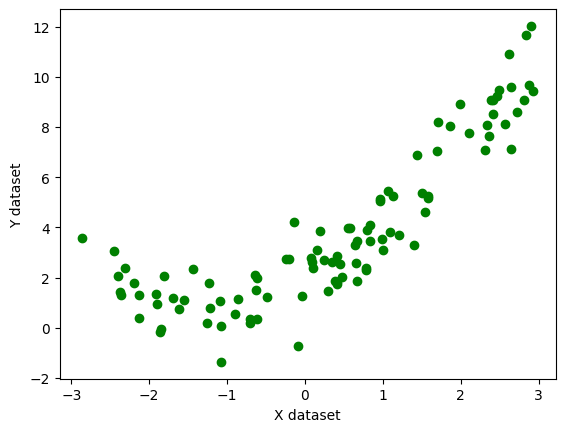

In [122]:
x = 6 * np.random.rand(100,1) - 3
y = 0.5 * x**2 + 1.5*x + 2 + np.random.randn(100,1)
# quardratic equation used y = 0.5x^2 + 1.5x + 2 + outlieres 
plt.scatter(x,y,color= 'g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [123]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [124]:
# lets implement simple linear regrssion 
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [125]:
y_pred = model.predict(x_test)

In [126]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7423768304614298

Text(0, 0.5, 'Y dataset')

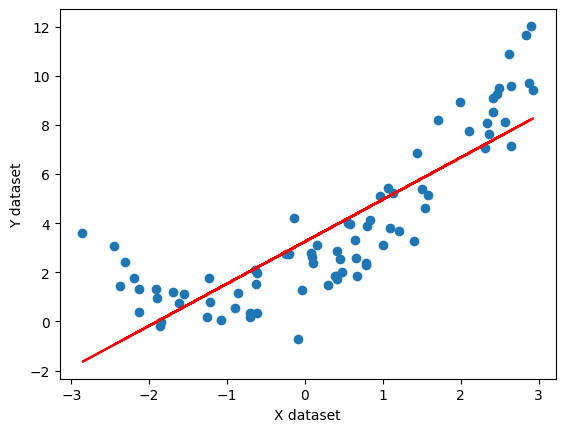

In [127]:
plt.scatter(x_train,y_train)
plt.plot(x_train,model.predict(x_train),color='r')
plt.xlabel("X dataset")
plt.ylabel("Y dataset")



In [128]:
# applying polynomial transformation
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3,include_bias=True) #bias means include beta0
# h(x) = beta0 + beta1*x + beta2*x^2

In [129]:
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [130]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(x_train_poly,y_train)
y_pred = regression.predict(x_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.8899642860452173


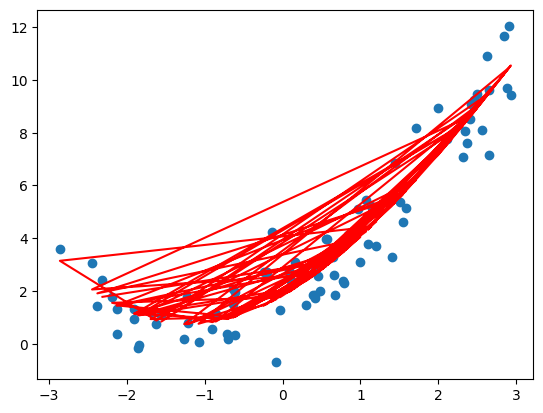

In [131]:
plt.scatter(x_train, y_train)
plt.plot(x_train, regression.predict(x_train_poly), color='r')



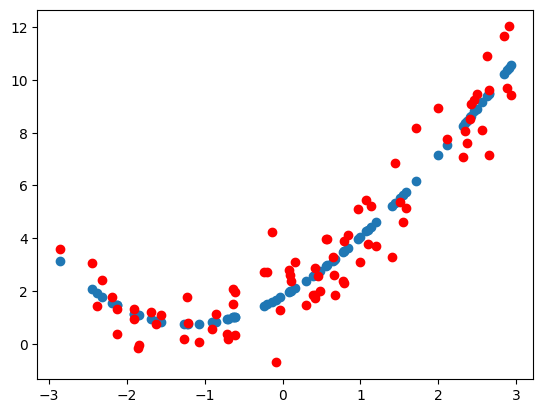

In [132]:
plt.scatter(x_train,regression.predict(x_train_poly))
plt.scatter(x_train,y_train,color='r')

In [133]:
# prediction of new data set
x_new = np.linspace(-2,2,200).reshape(200,1)
x_new_poly = poly.transform(x_new)
x_new_poly

array([[ 1.00000000e+00, -2.00000000e+00,  4.00000000e+00,
        -8.00000000e+00],
       [ 1.00000000e+00, -1.97989950e+00,  3.92000202e+00,
        -7.76121003e+00],
       [ 1.00000000e+00, -1.95979899e+00,  3.84081210e+00,
        -7.52721969e+00],
       [ 1.00000000e+00, -1.93969849e+00,  3.76243024e+00,
        -7.29798027e+00],
       [ 1.00000000e+00, -1.91959799e+00,  3.68485644e+00,
        -7.07344302e+00],
       [ 1.00000000e+00, -1.89949749e+00,  3.60809070e+00,
        -6.85355923e+00],
       [ 1.00000000e+00, -1.87939698e+00,  3.53213303e+00,
        -6.63828016e+00],
       [ 1.00000000e+00, -1.85929648e+00,  3.45698341e+00,
        -6.42755709e+00],
       [ 1.00000000e+00, -1.83919598e+00,  3.38264185e+00,
        -6.22134130e+00],
       [ 1.00000000e+00, -1.81909548e+00,  3.30910836e+00,
        -6.01958404e+00],
       [ 1.00000000e+00, -1.79899497e+00,  3.23638292e+00,
        -5.82223661e+00],
       [ 1.00000000e+00, -1.77889447e+00,  3.16446554e+00,
      

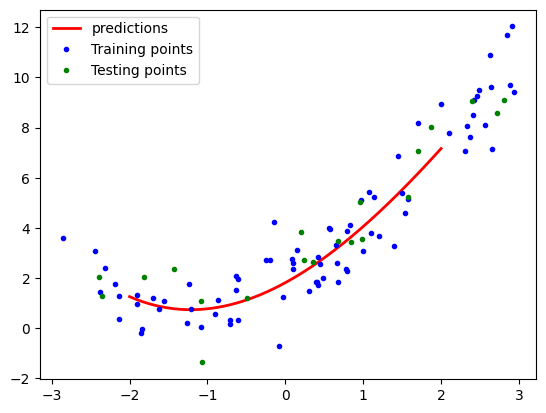

In [134]:
y_new = regression.predict(x_new_poly)
plt.plot(x_new,y_new,'r-',linewidth=2,label = "predictions")
plt.plot(x_train,y_train,"b.",label="Training points")
plt.plot(x_test,y_test,"g.", label = 'Testing points')
plt.legend()
plt.show()

In [135]:
from sklearn.pipeline import Pipeline

In [ ]:
def poly_regression(degree):
    x_new = np.linspace(-3,3,200).reshape(200,1)
    x_new_poly = poly.transform(x_new)
    poly_features = PolynomialFeatures(degree = degree,include_bias=True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ("poly_feature", poly_features),
        ('lin_reg',lin_reg)
    ])
    poly_regression.fit(x_train,y_train)      #first create polynomial and then linear regression
    y_pred_new = poly_regression.predict(x_new)
    plt.plot(x_new,y_pred_new,'r',label="degree")
    plt.plot(x_train,y_train,"b.",linewidth=3)
    plt.legend(loc="upper left")
    plt.axis([-4,4,0,10])
    plt.show()
    

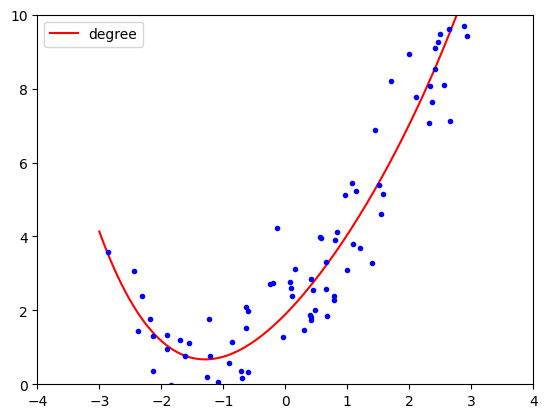

In [144]:
poly_regression(4)